# Multi-Compartment HH network demo

This notebook builds two small populations of single-cable Hodgkin-Huxley cells and connects them through the `braincell.network` API. Each cell has a soma cable with sodium (`Na_HH1952`), potassium (`K_HH1952`), and leak (`IL`) channels.

The presynaptic population receives brief soma current clamps. `Network.add_edges(...)` samples a probabilistic E-to-I cell-level graph from `n_pre`, `n_post`, and `connection_probability`, and `Network.add_projection(...)` maps those edges to the placed postsynaptic `ExpSyn` pool. Projection weights are event payloads with units (`u.uS` here), and zero declared delay still uses fixed-step next-step delivery.


In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cuda"

import sys
from pathlib import Path


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
import braincell.mech as mech
from braincell import Branch, CVPerBranch, Cell, Morphology
from braincell.filter import AllRegion, at

print("braincell version:", braincell.__version__)
print("repo_root:", repo_root)
import brainstate
brainstate.environ.set(precision=64)

braincell version: 0.1.0
repo_root: /home/swl/braincell


In [2]:
def build_single_cable_morphology() -> Morphology:
    soma = Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    return Morphology.from_root(soma, name="soma")


def add_hh_membrane(cell: Cell) -> None:
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=0.3 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    )


def pulse_protocol(size: int) -> tuple[mech.CurrentClamp, mech.CurrentClamp]:
    base_delays = np.asarray([5.0, 5.2, 5.4], dtype=float)
    input_delays = base_delays[np.arange(size) % len(base_delays)]
    pulse_width = 0.1 * u.ms
    repeat_delay = 22.0
    amplitudes = u.Quantity(1.0 + 0.02 * np.arange(size, dtype=float), u.nA)

    return (
        mech.CurrentClamp(
            delay=u.Quantity(input_delays, u.ms),
            durations=pulse_width,
            amplitudes=amplitudes,
        ),
        mech.CurrentClamp(
            delay=u.Quantity(input_delays + repeat_delay, u.ms),
            durations=pulse_width,
            amplitudes=amplitudes,
        ),
    )


def build_pre_cell(size=10) -> Cell:
    cell = Cell(
        build_single_cable_morphology(),
        cv_policy=CVPerBranch(),
        pop_size=(size,),
        solver="staggered",
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name="pre",
    )
    add_hh_membrane(cell)

    cell.place(at("soma", 0.5), *pulse_protocol(size=size))
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    return cell


def build_post_cell(size=10) -> Cell:
    cell = Cell(
        build_single_cable_morphology(),
        cv_policy=CVPerBranch(),
        pop_size=(size,),
        solver="staggered",
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name="post",
    )
    add_hh_membrane(cell)
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
    cell.place(at("soma", 0.5), mech.MechanismProbe(name="g_syn", mechanism="exp", field="g"))
    cell.place(at("soma", 0.5), mech.CurrentProbe(name="i_syn", mechanism="exp"))
    cell.place(
        at("soma", 0.5),
        mech.Synapse(
            "ExpSyn",
            tau=2.0 * u.ms,
            e=0.0 * u.mV,
            weight=1.0 * u.uS,
            name="exp",
        ),
    )
    return cell


def initialize_to_steady_state(*cells: Cell) -> None:
    for cell in cells:
        cell.init_state()
        cell.reset_state()


In [3]:
# Build two one-dimensional homogeneous HH populations.
n_pre = 100
n_post = 100
connection_probability = 0.35
connection_seed = 7
synaptic_weight = 0.001 * u.uS

pre = build_pre_cell(size=n_pre)
post = build_post_cell(size=n_post)
initialize_to_steady_state(pre, post)

net = braincell.Network(name="hh_demo")
net.add_population("E", pre)
net.add_population("I", post)
edges = net.add_edges(
    name="E_to_I",
    pre="E",
    post="I",
    method=braincell.network.probability(
        p=connection_probability,
        seed=connection_seed,
    ),
)
pre_index = edges.pre_index
post_index = edges.post_index
weights = np.full(edges.n_edge, synaptic_weight.to_decimal(u.uS), dtype=float) * u.uS

net.add_projection(
    name="E_to_I_exp",
    edges="E_to_I",
    synapse_pool="exp",
    weight=weights,
    delay=0.0 * u.ms,
)

result = net.run(dt=0.05 * u.ms, duration=500.0 * u.ms)
result


NetworkRunResult(time=Quantity([0.0000e+00 5.0000e-02 1.0000e-01 ... 4.9985e+02 4.9990e+02 4.9995e+02], "ms"), traces={'E': {'v': Quantity([[-65.31896772 -64.99979573 -65.31896772 ... -65.31896772 -65.31896772
           -65.31896772]
          [-65.62845274 -64.99959742 -65.62845274 ... -65.62845274 -65.62845274
           -65.62845274]
          [-65.92942838 -64.99940432 -65.92942838 ... -65.92942838 -65.92942838
           -65.92942838]
          ...
          [-68.5688203  -64.99637933 -68.5688203  ... -68.5688203  -68.5688203
           -68.5688203 ]
          [-68.5688203  -64.99637933 -68.5688203  ... -68.5688203  -68.5688203
           -68.5688203 ]
          [-68.5688203  -64.99637933 -68.5688203  ... -68.5688203  -68.5688203
           -68.5688203 ]], "mV")}, 'I': {'g_syn': Quantity([[0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 0.00000000e+000
           0.00000000e+000 0.00000000e+000]
          [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 0.00000000e+000
  

In [4]:
# Inspect result shapes and verify event delivery.
def trace_2d(value, unit):
    arr = np.asarray(value.to_decimal(unit), dtype=float)
    return arr.reshape((arr.shape[0], -1))


def array_2d(value):
    arr = np.asarray(value, dtype=float)
    return arr.reshape((arr.shape[0], -1))


def first_crossing_step(cross):
    steps = np.flatnonzero(np.any(cross, axis=1))
    return None if steps.size == 0 else int(steps[0] + 1)


time_ms = np.asarray(result.time.to_decimal(u.ms), dtype=float)
pre_v_mV = trace_2d(result.traces["E"]["v"], u.mV)
post_v_mV = trace_2d(result.traces["I"]["v"], u.mV)
post_g_uS = trace_2d(result.traces["I"]["g_syn"], u.uS)
post_i_nA = trace_2d(result.traces["I"]["i_syn"], u.nA)
pre_spike = array_2d(result.spikes["E"])

pre_cross = (pre_v_mV[:-1] < 0.0) & (pre_v_mV[1:] >= 0.0)
post_cross = (post_v_mV[:-1] < 0.0) & (post_v_mV[1:] >= 0.0)
post_received = post_g_uS > 0.0
first_pre_step = first_crossing_step(pre_cross)
first_post_step = first_crossing_step(post_cross)
pre_spike_count = pre_cross.sum(axis=0)
post_spike_count = post_cross.sum(axis=0)
pre_spike_times = [time_ms[np.flatnonzero(pre_cross[:, idx]) + 1] for idx in range(n_pre)]
post_first_spike_times = np.full(n_post, np.nan)
inputs_before_post_spike = np.zeros(n_post, dtype=int)
for post_idx in range(n_post):
    post_steps = np.flatnonzero(post_cross[:, post_idx])
    if post_steps.size == 0:
        continue
    first_time = time_ms[post_steps[0] + 1]
    post_first_spike_times[post_idx] = first_time
    sources = pre_index[post_index == post_idx]
    inputs_before_post_spike[post_idx] = sum(np.any(pre_spike_times[src] < first_time) for src in sources)

print("time shape:", result.time.shape)
print("E.v shape:", result.traces["E"]["v"].shape)
print("I.v shape:", result.traces["I"]["v"].shape)
print("I.g_syn shape:", result.traces["I"]["g_syn"].shape)
print("E spike shape:", result.spikes["E"].shape)
print("connection probability:", connection_probability, "seed:", connection_seed)
print("connection count:", edges.n_edge)
print("first 12 edge pairs:", list(zip(pre_index[:12].tolist(), post_index[:12].tolist())))
if first_pre_step is None:
    print("first E voltage crossing: none")
else:
    print("first E voltage crossing step:", first_pre_step, "time_ms:", time_ms[first_pre_step])
if first_post_step is None:
    print("first I voltage crossing: none")
else:
    print("first I voltage crossing step:", first_post_step, "time_ms:", time_ms[first_post_step])
print("E crossing count by cell:", pre_spike_count)
print("I crossing count by cell:", post_spike_count)
print("I first spike times ms:", post_first_spike_times)
print("pre inputs before first I spike:", inputs_before_post_spike)
print("postsynaptic conductance ever positive:", np.any(post_received, axis=0))
print("network spike buffer matches voltage crossing count:", pre_spike.sum(axis=0).astype(int))


time shape: (10000,)
E.v shape: (10000, 100)
I.v shape: (10000, 100)
I.g_syn shape: (10000, 100)
E spike shape: (10000, 100, 1)
connection probability: 0.35 seed: 7
connection count: 3543
first 12 edge pairs: [(0, 3), (0, 4), (0, 6), (0, 10), (0, 11), (0, 12), (0, 20), (0, 21), (0, 23), (0, 24), (0, 31), (0, 32)]
first E voltage crossing step: 107 time_ms: 5.3500000000000005
first I voltage crossing step: 123 time_ms: 6.15
E crossing count by cell: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
I crossing count by cell: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
I first spike times ms: [6.2  6.3  6.35 6.3  6.4  6.25 6.3  6.3  6.2  6.25 6.35 6.2  6.3  6.2
 6.25 6.25 6.25 6.3

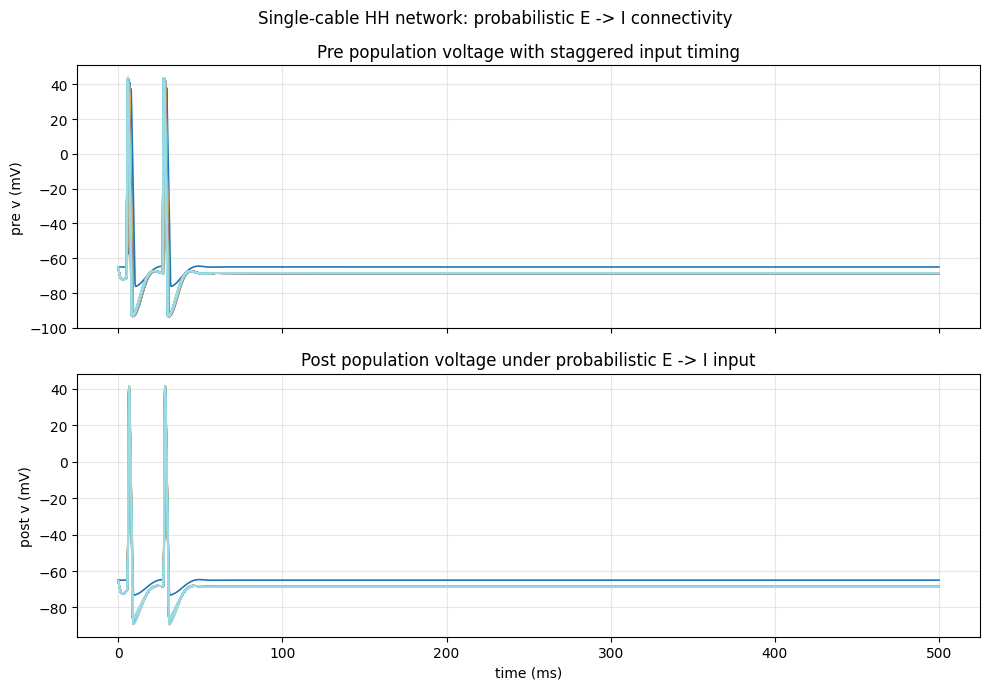

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
pre_colors = plt.cm.tab20(np.linspace(0.0, 1.0, max(n_pre, 1)))
post_colors = plt.cm.tab20(np.linspace(0.0, 1.0, max(n_post, 1)))

for idx in range(n_pre):
    axes[0].plot(time_ms, pre_v_mV[:, idx], color=pre_colors[idx], linewidth=1.2, label=f"E[{idx}]")
axes[0].set_ylabel("pre v (mV)")
axes[0].set_title("Pre population voltage with staggered input timing")

for idx in range(n_post):
    axes[1].plot(time_ms, post_v_mV[:, idx], color=post_colors[idx], linewidth=1.2, label=f"I[{idx}]")
axes[1].set_ylabel("post v (mV)")
axes[1].set_xlabel("time (ms)")
axes[1].set_title("Post population voltage under probabilistic E -> I input")

for axis, n_label in zip(axes, (n_pre, n_post)):
    axis.grid(True, alpha=0.3)
    if n_label <= 20:
        axis.legend(loc="upper right", ncol=min(5, n_label), fontsize=8)

fig.suptitle("Single-cable HH network: probabilistic E -> I connectivity")
fig.tight_layout()
plt.show()
